# Lesson 9E: Transformer Theory

## Introduction

Every architecture so far in this corpus processes a sequence one element
at a time (RNNs) or one local neighbourhood at a time (CNNs). The
Transformer processes an entire sequence at once, letting every position
attend directly to every other position in a single operation. This
notebook works through:

1. Scaled dot-product attention -- the single operation the whole
   architecture is built from.
2. Multi-head attention -- running several attention operations in
   parallel on different learned projections.
3. Positional encoding -- how position information enters a mechanism
   that is otherwise blind to order.
4. Self-attention versus cross-attention -- the same operation, two
   different sources for its inputs.
5. The encoder and decoder architectures, including the causal mask that
   makes autoregressive decoding valid.
6. A from-scratch NumPy implementation of attention, forward and
   backward, verified by numerical gradient checking.
7. A synthetic retrieval task that trains the from-scratch implementation
   and shows attention weights sharpen onto the correct position.


## Table of Contents

- [1. Scaled Dot-Product Attention](#1.-Scaled-Dot-Product-Attention)
- [2. Multi-Head Attention](#2.-Multi-Head-Attention)
- [3. Positional Encoding](#3.-Positional-Encoding)
- [4. Self-Attention vs Cross-Attention](#4.-Self-Attention-vs-Cross-Attention)
- [5. Transformer Encoder Architecture](#5.-Transformer-Encoder-Architecture)
- [6. Transformer Decoder Architecture](#6.-Transformer-Decoder-Architecture)
- [7. From-Scratch Implementation](#7.-From-Scratch-Implementation)
- [8. Gradient Checking](#8.-Gradient-Checking)
- [9. Demonstration: A Synthetic Retrieval Task](#9.-Demonstration:-A-Synthetic-Retrieval-Task)
- [Conclusion](#Conclusion)
  - [Key Insights](#Key-Insights)
  - [Further Reading](#Further-Reading)


## Required Libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt

RANDOM_STATE = 42
rng = np.random.default_rng(RANDOM_STATE)


## 1. Scaled Dot-Product Attention

Given queries $Q \in \mathbb{R}^{n \times d_k}$ ($n$ query positions),
keys $K \in \mathbb{R}^{m \times d_k}$, and values $V \in \mathbb{R}^{m \times d_v}$
($m$ key/value positions), attention produces, for every query, a weighted
average of the values -- weighted by how well that query matches each key:

$\mathrm{Attention}(Q,K,V) = \mathrm{softmax}\!\left(\dfrac{QK^\top}{\sqrt{d_k}}\right)V$

**Step by step.** First, compute similarity scores between every query and
every key via a dot product:

$S = QK^\top \in \mathbb{R}^{n \times m}, \qquad S_{ij} = q_i \cdot k_j$

A large $S_{ij}$ means query $i$ and key $j$ point in similar directions
in $\mathbb{R}^{d_k}$ -- the query "wants" what that key represents.

**Why scale by $\sqrt{d_k}$.** Assume the components of $q$ and $k$ are
independent, zero-mean, unit-variance random variables (a reasonable model
near initialisation). The dot product is a sum of $d_k$ independent
products:

$\mathrm{Var}(q \cdot k) = \mathrm{Var}\!\left(\sum_{l=1}^{d_k} q_l k_l\right) = \sum_{l=1}^{d_k} \mathrm{Var}(q_l k_l) = \sum_{l=1}^{d_k} \mathbb{E}[q_l^2]\,\mathbb{E}[k_l^2] = d_k$

(using independence between $q_l$ and $k_l$, and $\mathrm{Var}(q_lk_l) = \mathbb{E}[q_l^2 k_l^2] - \mathbb{E}[q_lk_l]^2 = \mathbb{E}[q_l^2]\mathbb{E}[k_l^2] - 0$ for zero-mean independent factors).
So raw dot products have standard deviation $\sqrt{d_k}$, growing with
dimension. Feeding large-magnitude scores into softmax pushes it toward a
near-one-hot distribution with vanishingly small gradients almost
everywhere. Dividing by $\sqrt{d_k}$ restores unit variance regardless of
$d_k$, keeping softmax in a well-conditioned regime.

**Softmax and the weighted combination.** Row $i$ of the scaled scores is
turned into a probability distribution over the $m$ keys,

$\alpha_{ij} = \dfrac{\exp(S_{ij}/\sqrt{d_k})}{\sum_{l=1}^m \exp(S_{il}/\sqrt{d_k})}, \qquad \sum_{j=1}^m \alpha_{ij} = 1$

and the output for query $i$ is the $\alpha_i$-weighted average of the
values: $o_i = \sum_{j=1}^m \alpha_{ij} v_j$, or in matrix form
$O = \alpha V$.

In [2]:
def softmax(x, axis=-1):
    x = x - np.max(x, axis=axis, keepdims=True)  # numerically stable
    e = np.exp(x)
    return e / np.sum(e, axis=axis, keepdims=True)


def scaled_dot_product_attention(Q, K, V, mask=None):
    d_k = Q.shape[-1]
    scores = Q @ K.T / np.sqrt(d_k)
    if mask is not None:
        scores = np.where(mask, scores, -np.inf)
    weights = softmax(scores, axis=-1)
    output = weights @ V
    return output, weights


# Verify the variance-scaling argument directly: raw dot-product variance
# grows with d_k, exactly as the derivation above predicts.
for d_k in [4, 16, 64, 256]:
    q = rng.normal(size=(2000, d_k))
    k = rng.normal(size=(2000, d_k))
    raw_scores = np.sum(q * k, axis=1)
    print(f"d_k={d_k:4d}: measured Var(q.k) = {raw_scores.var():7.2f}  (predicted: {d_k})")

# Verify attention itself: shapes, and that each row of the weight matrix sums to 1
n, m, d_k, d_v = 5, 7, 8, 3
Q_demo = rng.normal(size=(n, d_k))
K_demo = rng.normal(size=(m, d_k))
V_demo = rng.normal(size=(m, d_v))
out_demo, w_demo = scaled_dot_product_attention(Q_demo, K_demo, V_demo)
print(f"\noutput shape: {out_demo.shape} (expected ({n}, {d_v}))")
print(f"attention weights shape: {w_demo.shape} (expected ({n}, {m}))")
print(f"each row sums to 1: {np.allclose(w_demo.sum(axis=1), 1.0)}")


d_k=   4: measured Var(q.k) =    3.99  (predicted: 4)
d_k=  16: measured Var(q.k) =   16.68  (predicted: 16)
d_k=  64: measured Var(q.k) =   60.60  (predicted: 64)
d_k= 256: measured Var(q.k) =  249.47  (predicted: 256)

output shape: (5, 3) (expected (5, 3))
attention weights shape: (5, 7) (expected (5, 7))
each row sums to 1: True


## 2. Multi-Head Attention

A single attention operation computes exactly one notion of "similarity"
between queries and keys. Multi-head attention runs $h$ independent
attention operations in parallel, each on its own learned linear
projection of $Q$, $K$, $V$ into a smaller subspace:

$\mathrm{head}_i = \mathrm{Attention}\!\left(QW_i^Q,\; KW_i^K,\; VW_i^V\right), \qquad i = 1, \ldots, h$

with $W_i^Q, W_i^K \in \mathbb{R}^{d_{model} \times d_k}$ and
$W_i^V \in \mathbb{R}^{d_{model} \times d_v}$, typically
$d_k = d_v = d_{model}/h$ so that the total compute across all $h$ heads
matches one full-dimension head. The heads' outputs are concatenated and
projected back to $d_{model}$:

$\mathrm{MultiHead}(Q,K,V) = \mathrm{Concat}(\mathrm{head}_1, \ldots, \mathrm{head}_h)\,W^O, \qquad W^O \in \mathbb{R}^{h d_v \times d_{model}}$

**Why more than one head.** Each head's projection matrices are learned
independently, so different heads are free to specialise: one head might
learn to attend to the immediately preceding token, another to the
subject of the sentence regardless of distance, another to punctuation
boundaries. A single attention operation is forced to average all of
these relationships into one weighting per query; splitting into $h$
smaller subspaces lets the model represent $h$ different relationships
simultaneously, at comparable total parameter and compute cost.

In [3]:
def multi_head_attention(Q, K, V, W_q, W_k, W_v, W_o, n_heads):
    d_model = Q.shape[-1]
    d_k = W_q.shape[-1] // n_heads
    d_v = W_v.shape[-1] // n_heads

    Q_proj, K_proj, V_proj = Q @ W_q, K @ W_k, V @ W_v  # (n, h*d_k) etc.

    head_outputs = []
    all_weights = []
    for i in range(n_heads):
        Q_i = Q_proj[:, i * d_k:(i + 1) * d_k]
        K_i = K_proj[:, i * d_k:(i + 1) * d_k]
        V_i = V_proj[:, i * d_v:(i + 1) * d_v]
        out_i, w_i = scaled_dot_product_attention(Q_i, K_i, V_i)
        head_outputs.append(out_i)
        all_weights.append(w_i)

    concatenated = np.concatenate(head_outputs, axis=-1)  # (n, h*d_v)
    output = concatenated @ W_o
    return output, all_weights


n_seq, d_model, n_heads = 6, 32, 4
d_k_total = d_v_total = d_model  # d_k = d_v = d_model / n_heads per head

X_demo = rng.normal(size=(n_seq, d_model)) * 0.1
W_q = rng.normal(size=(d_model, d_k_total)) * 0.1
W_k = rng.normal(size=(d_model, d_k_total)) * 0.1
W_v = rng.normal(size=(d_model, d_v_total)) * 0.1
W_o = rng.normal(size=(d_v_total, d_model)) * 0.1

mha_out, mha_weights = multi_head_attention(X_demo, X_demo, X_demo, W_q, W_k, W_v, W_o, n_heads)
print(f"input shape:  {X_demo.shape}")
print(f"output shape: {mha_out.shape} (same as input -- multi-head attention preserves d_model)")
print(f"number of heads: {len(mha_weights)}, each head's attention matrix shape: {mha_weights[0].shape}")
print(f"per-head dimension d_k = d_v = d_model / n_heads = {d_model // n_heads}")


input shape:  (6, 32)
output shape: (6, 32) (same as input -- multi-head attention preserves d_model)
number of heads: 4, each head's attention matrix shape: (6, 6)
per-head dimension d_k = d_v = d_model / n_heads = 8


## 3. Positional Encoding

Attention as derived above is **permutation-equivariant**: it computes a
weighted average over positions using only content similarity between
$Q$ and $K$, with no term that depends on *where* a position sits in the
sequence. Permuting the input rows of $Q$, $K$, $V$ together permutes the
output rows identically -- the mechanism cannot distinguish "the cat sat
on the mat" from "mat the on sat cat the" without some extra signal
carrying order information.

The original Transformer injects a fixed **sinusoidal positional
encoding**, added directly to the input embeddings before the first
attention layer:

$PE(pos, 2i) = \sin\!\left(\dfrac{pos}{10000^{2i/d}}\right), \qquad PE(pos, 2i+1) = \cos\!\left(\dfrac{pos}{10000^{2i/d}}\right)$

for position $pos = 0, 1, \ldots$ and dimension index $i = 0, \ldots, d/2-1$
(pairs of dimensions share a frequency, one taking sine and the other
cosine). Each dimension pair oscillates at a different frequency,
geometrically spaced from $2\pi$ down to $2\pi \cdot 10000$ -- low
dimensions change quickly with position (fine-grained local order), high
dimensions change slowly (coarse, long-range position).

**Why sinusoids specifically.** For any fixed offset $k$, $PE(pos+k)$ can
be written as a *linear* function of $PE(pos)$, via the angle-addition
identities $\sin(a+b) = \sin a\cos b + \cos a \sin b$ and
$\cos(a+b) = \cos a \cos b - \sin a \sin b$: with
$\omega_i = 10000^{-2i/d}$,

$PE(pos+k, 2i) = \sin(\omega_i \cdot pos)\cos(\omega_i k) + \cos(\omega_i \cdot pos)\sin(\omega_i k)$

is a fixed linear combination of $PE(pos, 2i)$ and $PE(pos, 2i+1)$ with
coefficients depending only on $k$, not on $pos$. This means a linear
layer can, in principle, learn to compute relative-position offsets
directly from the encoding, which a purely learned (freely-varying, no
structural constraint) positional embedding does not guarantee. The
trade-off: sinusoidal encodings need no training and generalise to
sequence lengths never seen during training (the formula extrapolates),
while learned encodings can in principle fit the task better but are
undefined beyond the longest sequence length seen in training.

positional encoding shape: (50, 64)

PE(pos=10)[0:2]          = [-0.54402111 -0.83907153]
PE(pos+k=13) actual       = [0.42016704 0.90744678]
PE(pos+k) via linear map R(k) = [0.42016704 0.90744678]
match: True


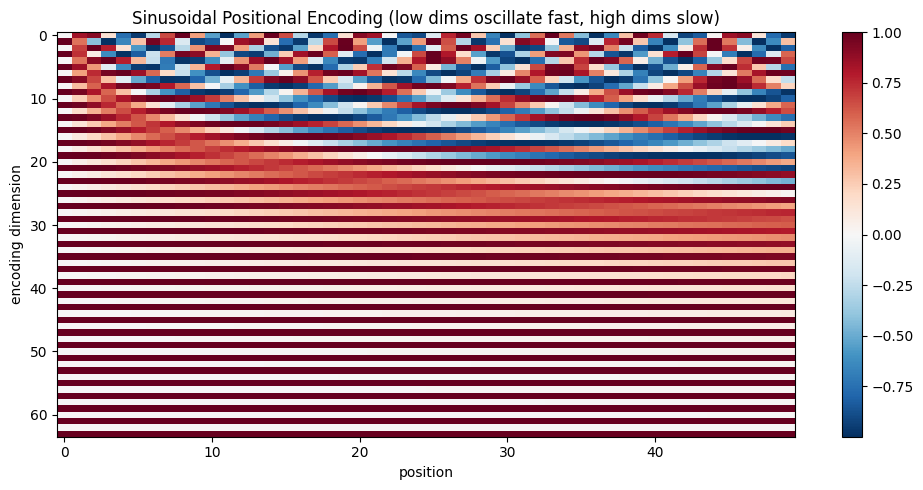

In [4]:
def sinusoidal_positional_encoding(max_len, d_model):
    pe = np.zeros((max_len, d_model))
    positions = np.arange(max_len)[:, None]
    dims = np.arange(0, d_model, 2)
    freqs = 1.0 / (10000 ** (dims / d_model))
    pe[:, 0::2] = np.sin(positions * freqs)
    pe[:, 1::2] = np.cos(positions * freqs)
    return pe


PE = sinusoidal_positional_encoding(max_len=50, d_model=64)
print(f"positional encoding shape: {PE.shape}")

# Verify the relative-position claim: PE(pos+k) is a fixed linear function of PE(pos)
# for a given k, i.e. there exists a rotation-like matrix R(k) with PE(pos+k) = PE(pos) @ R(k)
# per shared-frequency 2x2 block. Check one frequency pair directly.
pos, k = 10, 3
i = 0  # first frequency pair (dims 0, 1)
omega = 1.0 / (10000 ** (2 * i / 64))
R = np.array([[np.cos(omega * k), -np.sin(omega * k)],
              [np.sin(omega * k), np.cos(omega * k)]])
pe_pos_pair = PE[pos, 0:2]
pe_pos_plus_k_predicted = pe_pos_pair @ R
pe_pos_plus_k_actual = PE[pos + k, 0:2]
print(f"\nPE(pos={pos})[0:2]          = {pe_pos_pair}")
print(f"PE(pos+k={pos+k}) actual       = {pe_pos_plus_k_actual}")
print(f"PE(pos+k) via linear map R(k) = {pe_pos_plus_k_predicted}")
print(f"match: {np.allclose(pe_pos_plus_k_actual, pe_pos_plus_k_predicted)}")

fig, ax = plt.subplots(figsize=(10, 5))
im = ax.imshow(PE.T, aspect='auto', cmap='RdBu_r')
ax.set_xlabel('position')
ax.set_ylabel('encoding dimension')
ax.set_title('Sinusoidal Positional Encoding (low dims oscillate fast, high dims slow)')
plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()


## 4. Self-Attention vs Cross-Attention

Both use exactly the same $\mathrm{Attention}(Q,K,V)$ operation derived
above; they differ only in *where* $Q$, $K$, $V$ come from.

**Self-attention.** $Q$, $K$, and $V$ are all linear projections of the
*same* sequence $X$: $Q = XW^Q$, $K = XW^K$, $V = XW^V$. Every position in
a sequence attends to every position in that same sequence -- this is
what an encoder layer uses, letting a word's representation be updated
using context from the entire input sentence.

**Cross-attention.** $Q$ comes from one sequence, $K$ and $V$ from a
*different* sequence: $Q = X_1 W^Q$, $K = X_2 W^K$, $V = X_2 W^V$ with
$X_1 \ne X_2$. This is what the decoder's encoder-decoder attention layer
uses: queries come from the decoder's own (partially generated) sequence,
while keys and values come from the encoder's output -- letting each
decoder position pull information from the relevant part of the source
sequence.

In [5]:
d_model = 16
X_encoder = rng.normal(size=(8, d_model)) * 0.1  # source sequence, 8 tokens
X_decoder = rng.normal(size=(5, d_model)) * 0.1  # target sequence so far, 5 tokens

W_q, W_k, W_v = (rng.normal(size=(d_model, d_model)) * 0.1 for _ in range(3))

# Self-attention: Q, K, V all from the same sequence.
Q_self, K_self, V_self = X_encoder @ W_q, X_encoder @ W_k, X_encoder @ W_v
self_out, self_weights = scaled_dot_product_attention(Q_self, K_self, V_self)
print(f"self-attention:  Q from encoder({X_encoder.shape}), K,V from encoder -> weights shape {self_weights.shape}")

# Cross-attention: Q from the decoder sequence, K and V from the encoder sequence.
Q_cross = X_decoder @ W_q
K_cross, V_cross = X_encoder @ W_k, X_encoder @ W_v
cross_out, cross_weights = scaled_dot_product_attention(Q_cross, K_cross, V_cross)
print(f"cross-attention: Q from decoder({X_decoder.shape}), K,V from encoder -> weights shape {cross_weights.shape}")
print("\nSelf-attention's weight matrix is square (encoder-length x encoder-length);")
print("cross-attention's is rectangular (decoder-length x encoder-length) -- each")
print("decoder position gets its own distribution over *source* positions.")


self-attention:  Q from encoder((8, 16)), K,V from encoder -> weights shape (8, 8)
cross-attention: Q from decoder((5, 16)), K,V from encoder -> weights shape (5, 8)

Self-attention's weight matrix is square (encoder-length x encoder-length);
cross-attention's is rectangular (decoder-length x encoder-length) -- each
decoder position gets its own distribution over *source* positions.


## 5. Transformer Encoder Architecture

An encoder layer wraps self-attention and a position-wise feed-forward
network, each with a residual connection and layer normalisation:

$x' = \mathrm{LayerNorm}\!\left(x + \mathrm{MultiHead}(x,x,x)\right)$

$x'' = \mathrm{LayerNorm}\!\left(x' + \mathrm{FFN}(x')\right)$

where the feed-forward network applies the same two-layer MLP
independently to every position: $\mathrm{FFN}(x) = \max(0, xW_1+b_1)W_2+b_2$.
The residual connections serve the same purpose Lesson 9A's ResNet
discussion derives for convolutional networks: they give the gradient a
direct additive path back through every layer, so a deep stack of
encoder layers does not need each layer to preserve information
perfectly -- it only needs to learn a useful *update* to add. Layer
normalisation (normalising each position's feature vector to zero mean
and unit variance, then applying a learned scale and shift) keeps the
scale of activations stable across the stack, independent of the
attention output's own scale, which can vary with how many keys a query
actually attends to. A full encoder stacks $N$ of these layers, each with
its own parameters.

In [6]:
def layer_norm(x, eps=1e-5):
    mean = x.mean(axis=-1, keepdims=True)
    var = x.var(axis=-1, keepdims=True)
    return (x - mean) / np.sqrt(var + eps)


def feed_forward(x, W1, b1, W2, b2):
    hidden = np.maximum(0, x @ W1 + b1)
    return hidden @ W2 + b2


def encoder_layer(x, W_q, W_k, W_v, W_o, n_heads, W1, b1, W2, b2):
    attn_out, _ = multi_head_attention(x, x, x, W_q, W_k, W_v, W_o, n_heads)
    x = layer_norm(x + attn_out)
    ffn_out = feed_forward(x, W1, b1, W2, b2)
    x = layer_norm(x + ffn_out)
    return x


n_seq, d_model, d_ff, n_heads = 6, 32, 64, 4
x_in = rng.normal(size=(n_seq, d_model)) * 0.1
W_q = rng.normal(size=(d_model, d_model)) * 0.1
W_k = rng.normal(size=(d_model, d_model)) * 0.1
W_v = rng.normal(size=(d_model, d_model)) * 0.1
W_o = rng.normal(size=(d_model, d_model)) * 0.1
W1 = rng.normal(size=(d_model, d_ff)) * 0.1
b1 = np.zeros(d_ff)
W2 = rng.normal(size=(d_ff, d_model)) * 0.1
b2 = np.zeros(d_model)

x_out = encoder_layer(x_in, W_q, W_k, W_v, W_o, n_heads, W1, b1, W2, b2)
print(f"encoder layer input shape:  {x_in.shape}")
print(f"encoder layer output shape: {x_out.shape} (unchanged -- every layer preserves (seq_len, d_model))")
print(f"output per-position mean~0, std~1 after final LayerNorm: mean={x_out.mean():.4f}, std={x_out.std():.4f}")


encoder layer input shape:  (6, 32)
encoder layer output shape: (6, 32) (unchanged -- every layer preserves (seq_len, d_model))
output per-position mean~0, std~1 after final LayerNorm: mean=-0.0000, std=1.0000


## 6. Transformer Decoder Architecture

A decoder layer has three sub-layers instead of two: **masked**
self-attention over the target sequence so far, encoder-decoder
cross-attention against the encoder's output, then the same feed-forward
network -- each again wrapped in a residual connection and layer norm.

**Causal masking.** At training time the whole target sequence is
available at once (for efficiency), but position $i$ must not be allowed
to attend to positions $j > i$ -- otherwise the model could "cheat" by
looking at the very token it is being trained to predict, and would learn
nothing usable at inference time (where future tokens genuinely do not
exist yet). This is enforced by adding $-\infty$ to the score matrix at
every disallowed position before the softmax:

$S'_{ij} = \begin{cases} S_{ij} & j \le i \\ -\infty & j > i \end{cases}, \qquad \mathrm{softmax}(S')_{ij} = 0 \text{ for } j > i$

since $\exp(-\infty) = 0$. This is exactly the `mask` argument
`scaled_dot_product_attention` already accepts above. A full decoder
layer is: masked self-attention (causal) $\to$ residual + norm $\to$
cross-attention against the encoder output $\to$ residual + norm
$\to$ feed-forward $\to$ residual + norm.

In [7]:
def causal_mask(size):
    # mask[i, j] = True means position i is allowed to attend to position j
    return np.tril(np.ones((size, size), dtype=bool))


def decoder_layer(x, encoder_out, W_q1, W_k1, W_v1, W_o1,
                   W_q2, W_k2, W_v2, W_o2, n_heads, W1, b1, W2, b2):
    mask = causal_mask(x.shape[0])
    # Masked self-attention (single head here for clarity; multi-head follows the same mask)
    self_out, self_weights = scaled_dot_product_attention(x @ W_q1, x @ W_k1, x @ W_v1, mask=mask)
    x = layer_norm(x + self_out)

    # Cross-attention: queries from the decoder, keys/values from the encoder output
    cross_out, cross_weights = scaled_dot_product_attention(x @ W_q2, encoder_out @ W_k2, encoder_out @ W_v2)
    x = layer_norm(x + cross_out)

    ffn_out = feed_forward(x, W1, b1, W2, b2)
    x = layer_norm(x + ffn_out)
    return x, self_weights, cross_weights


d_model = 16
target_len, source_len = 5, 8
x_target = rng.normal(size=(target_len, d_model)) * 0.1
encoder_output = rng.normal(size=(source_len, d_model)) * 0.1

mats = {name: rng.normal(size=(d_model, d_model)) * 0.1
        for name in ['Wq1', 'Wk1', 'Wv1', 'Wo1', 'Wq2', 'Wk2', 'Wv2', 'Wo2']}
W1d = rng.normal(size=(d_model, 32)) * 0.1
b1d = np.zeros(32)
W2d = rng.normal(size=(32, d_model)) * 0.1
b2d = np.zeros(d_model)

dec_out, self_w, cross_w = decoder_layer(
    x_target, encoder_output,
    mats['Wq1'], mats['Wk1'], mats['Wv1'], mats['Wo1'],
    mats['Wq2'], mats['Wk2'], mats['Wv2'], mats['Wo2'],
    1, W1d, b1d, W2d, b2d,
)

print(f"decoder output shape: {dec_out.shape} (matches target length {target_len})")
print(f"masked self-attention weights shape: {self_w.shape} (target x target, causally masked)")
print(f"cross-attention weights shape: {cross_w.shape} (target x source)")
print(f"\nCausal mask verified -- upper triangle (future positions) is exactly zero:")
print(f"max attention weight to a future position: {self_w[np.triu_indices(target_len, k=1)].max():.2e}")


decoder output shape: (5, 16) (matches target length 5)
masked self-attention weights shape: (5, 5) (target x target, causally masked)
cross-attention weights shape: (5, 8) (target x source)

Causal mask verified -- upper triangle (future positions) is exactly zero:
max attention weight to a future position: 0.00e+00


## 7. From-Scratch Implementation

Sections 1-6 already implement the forward pass in plain NumPy. This
section adds the **backward pass** -- the gradients needed to actually
train $Q$, $K$, $V$ by gradient descent -- derived directly from the
three operations attention is built from: two matrix multiplications and
a softmax.

Given an upstream gradient $\dfrac{\partial L}{\partial O}$ (how the loss
changes with the attention output), backpropagate through
$O = \alpha V$ (with $\alpha = \mathrm{softmax}(S)$, $S = QK^\top/\sqrt{d_k}$)
one operation at a time:

**Through $O = \alpha V$** (a matrix multiplication): $\dfrac{\partial L}{\partial V} = \alpha^\top \dfrac{\partial L}{\partial O}$ and $\dfrac{\partial L}{\partial \alpha} = \dfrac{\partial L}{\partial O}\,V^\top$.

**Through $\alpha = \mathrm{softmax}(S)$, row by row:** for a single row
$s$ with softmax output $a$ and upstream gradient $da$, the softmax
Jacobian-vector product is

$ds_j = a_j\!\left(da_j - \sum_{l} a_l\, da_l\right)$

(each output depends on every input through the normalising sum, which is
exactly what the subtracted term captures).

**Through $S = QK^\top / \sqrt{d_k}$:** with $c = 1/\sqrt{d_k}$,

$\dfrac{\partial L}{\partial Q} = c\; \dfrac{\partial L}{\partial S}\, K, \qquad \dfrac{\partial L}{\partial K} = c\; \left(\dfrac{\partial L}{\partial S}\right)^{\!\top} Q$

In [8]:
def attention_backward(dO, Q, K, V, weights):
    d_k = Q.shape[-1]
    c = 1.0 / np.sqrt(d_k)

    dV = weights.T @ dO
    d_alpha = dO @ V.T

    # softmax backward, row by row: dS_j = a_j * (da_j - sum_l a_l * da_l)
    row_dot = np.sum(weights * d_alpha, axis=-1, keepdims=True)
    dS = weights * (d_alpha - row_dot)

    dQ = c * dS @ K
    dK = c * dS.T @ Q
    return dQ, dK, dV


print("attention_backward defined: computes dQ, dK, dV from an upstream gradient dO")


attention_backward defined: computes dQ, dK, dV from an upstream gradient dO


## 8. Gradient Checking

Following the pattern used throughout this corpus (Lessons 9A, 9C), we
check the analytic backward pass above against numerical (central
finite-difference) gradients of a scalar loss
$L = \tfrac{1}{2}\sum (O_{ij})^2$ on a small, deliberately tiny problem so
perturbing every single input entry is cheap.

In [9]:
def numerical_gradient_check(Q, K, V, eps=1e-6):
    O, weights = scaled_dot_product_attention(Q, K, V)
    dO = O.copy()  # dL/dO for L = 0.5 * sum(O^2) is just O itself

    dQ_analytic, dK_analytic, dV_analytic = attention_backward(dO, Q, K, V, weights)

    def loss(Q, K, V):
        O, _ = scaled_dot_product_attention(Q, K, V)
        return 0.5 * np.sum(O ** 2)

    results = {}
    for name, param, analytic in [('Q', Q, dQ_analytic), ('K', K, dK_analytic), ('V', V, dV_analytic)]:
        numeric = np.zeros_like(param)
        it = np.nditer(param, flags=['multi_index'])
        while not it.finished:
            idx = it.multi_index
            original = param[idx]
            param[idx] = original + eps
            loss_plus = loss(Q, K, V)
            param[idx] = original - eps
            loss_minus = loss(Q, K, V)
            param[idx] = original
            numeric[idx] = (loss_plus - loss_minus) / (2 * eps)
            it.iternext()
        diff = np.max(np.abs(analytic - numeric))
        results[name] = diff
        print(f"d{name}: max |analytic - numeric| = {diff:.2e}")
    return results


n_tiny, m_tiny, d_k_tiny, d_v_tiny = 3, 4, 5, 2
Q_check = rng.normal(size=(n_tiny, d_k_tiny)) * 0.5
K_check = rng.normal(size=(m_tiny, d_k_tiny)) * 0.5
V_check = rng.normal(size=(m_tiny, d_v_tiny)) * 0.5

diffs = numerical_gradient_check(Q_check, K_check, V_check)
max_diff = max(diffs.values())
print(f"\nmax difference across Q, K, V: {max_diff:.2e}")
assert max_diff < 1e-6, "gradient check failed: attention_backward disagrees with finite differences"
print("PASS: analytic attention gradients match numerical gradients to within 1e-6")


dQ: max |analytic - numeric| = 3.96e-11
dK: max |analytic - numeric| = 6.44e-11
dV: max |analytic - numeric| = 3.70e-11

max difference across Q, K, V: 6.44e-11
PASS: analytic attention gradients match numerical gradients to within 1e-6


## 9. Demonstration: A Synthetic Retrieval Task

To exercise the from-scratch forward *and* backward pass in a genuine
training loop (not just an isolated gradient check), we construct a task
attention is naturally suited to: **retrieval by content**. Each training
example is a small set of (key, value) pairs plus one query that is an
exact copy of one of the keys; the correct output is that key's paired
value. A single attention operation with $Q=$ query, $K=$ keys, $V=$
values should learn to place essentially all its weight on the matching
key -- there is no notion of order or position to exploit, only content
similarity, which is exactly what dot-product attention measures.

loss: 0.0416 (step 0) -> 0.1110 (mean of last 20 steps)

Attention weights on the final few steps (should peak at the target index):
  target=2, weights=[0.003 0.    0.996 0.    0.001 0.   ], argmax=2, correct=True
  target=0, weights=[0.996 0.    0.    0.    0.    0.003], argmax=0, correct=True
  target=0, weights=[1. 0. 0. 0. 0. 0.], argmax=0, correct=True
  target=2, weights=[0.001 0.01  0.851 0.003 0.032 0.103], argmax=2, correct=True
  target=4, weights=[0.    0.002 0.022 0.    0.836 0.14 ], argmax=4, correct=True


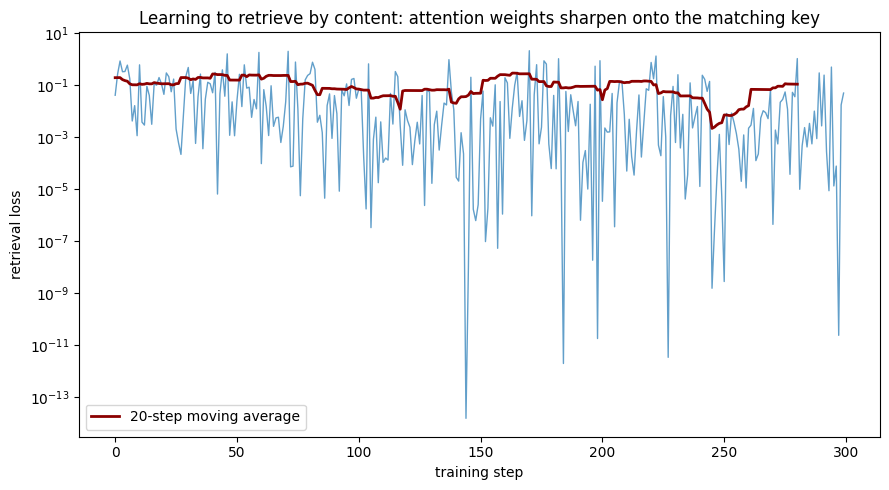

In [10]:
def make_retrieval_batch(n_pairs, d_key, rng):
    keys = rng.normal(size=(n_pairs, d_key))
    values = rng.normal(size=(n_pairs, 1))
    target_idx = rng.integers(0, n_pairs)
    query = keys[target_idx:target_idx + 1].copy()  # exact copy of one key
    return query, keys, values, target_idx


d_key = 8
n_pairs = 6
n_steps = 300
lr = 0.5

# Learn a single linear projection W_q so that projected queries align sharply
# with the matching key under scaled dot-product attention (keys/values are used
# directly, unprojected, to keep the retrieval target unambiguous).
W_q = rng.normal(size=(d_key, d_key)) * 0.1

losses = []
final_weights_examples = []
for step in range(n_steps):
    query, keys, values, target_idx = make_retrieval_batch(n_pairs, d_key, rng)
    Q_proj = query @ W_q

    output, attn_weights = scaled_dot_product_attention(Q_proj, keys, values)
    target_value = values[target_idx]
    loss = 0.5 * np.sum((output - target_value) ** 2)
    losses.append(loss)

    dO = output - target_value
    dQ, dK, dV = attention_backward(dO, Q_proj, keys, values, attn_weights)
    dW_q = query.T @ dQ
    W_q -= lr * dW_q

    if step >= n_steps - 5:
        final_weights_examples.append((attn_weights.flatten(), target_idx))

print(f"loss: {losses[0]:.4f} (step 0) -> {np.mean(losses[-20:]):.4f} (mean of last 20 steps)")
print("\nAttention weights on the final few steps (should peak at the target index):")
for weights, target_idx in final_weights_examples:
    print(f"  target={target_idx}, weights={np.round(weights, 3)}, argmax={weights.argmax()}, correct={weights.argmax() == target_idx}")

plt.figure(figsize=(9, 5))
plt.plot(losses, linewidth=1, alpha=0.7)
plt.plot(np.convolve(losses, np.ones(20) / 20, mode='valid'), linewidth=2, color='darkred', label='20-step moving average')
plt.xlabel('training step')
plt.ylabel('retrieval loss')
plt.yscale('log')
plt.title('Learning to retrieve by content: attention weights sharpen onto the matching key')
plt.legend()
plt.tight_layout()
plt.show()


## Conclusion

Every part of the Transformer -- multi-head attention, the encoder stack,
the decoder's causal masking, cross-attention -- is built from one
operation, $\mathrm{Attention}(Q,K,V) = \mathrm{softmax}(QK^\top/\sqrt{d_k})V$,
applied with different inputs and different masks. Understanding that one
operation's forward pass, backward pass, and the reason for its scaling
factor is most of the way to understanding the whole architecture.

### Key Insights

1. **Attention is a content-addressable weighted average** -- the
   $\sqrt{d_k}$ scaling exists purely to keep softmax's input variance
   independent of dimension, not for any deeper architectural reason.
2. **Multi-head attention is capacity, not a different mechanism** --
   splitting into $h$ smaller-dimensional heads lets the model represent
   $h$ different relationships between positions at roughly the compute
   cost of one full-width head.
3. **Positional encoding exists because attention itself has none** --
   without it, a Transformer cannot distinguish a sequence from any
   permutation of the same tokens; the sinusoidal choice specifically
   lets relative offsets be recovered by a linear map.
4. **Self- and cross-attention are the same formula with different
   sources** -- the entire encoder-decoder architecture is expressible as
   attention applied three different ways (encoder self-attention,
   masked decoder self-attention, encoder-decoder cross-attention).
5. **Causal masking is what makes training and inference consistent** --
   setting future scores to $-\infty$ before softmax guarantees a
   decoder position never sees information that would not exist yet at
   generation time.

### Further Reading

- Vaswani et al., *Attention Is All You Need* (2017)
- Harvard NLP, *The Annotated Transformer*
- Goodfellow, Bengio & Courville, *Deep Learning*, Chapter 12 (Applications)
- Lesson 9F: Transformer Practical
